In [1]:
import lightgbm as lgb

import os
import glob
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from scipy.stats import skew, kurtosis
from scipy.signal import find_peaks

In [2]:
TRAIN_DIR = "/kaggle/input/datasets/cheukhongtang/assig3/train/train"
TEST_DIR = "/kaggle/input/datasets/cheukhongtang/assig3/test/test"
SUB_PATH = "/kaggle/input/datasets/cheukhongtang/assig3/sample_submission.csv"

train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, "User_*", "*.csv")))
test_files = sorted(glob.glob(os.path.join(TEST_DIR, "User_*", "*.csv")))

print("Train files:", len(train_files))
print("Test files:", len(test_files))
print("Sample submission exists:", os.path.exists(SUB_PATH))

print(train_files[0])
print(test_files[0])

Train files: 11020
Test files: 6849
Sample submission exists: True
/kaggle/input/datasets/cheukhongtang/assig3/train/train/User_001/00001.csv
/kaggle/input/datasets/cheukhongtang/assig3/test/test/User_061/11021.csv


In [3]:
def get_user_from_path(path):
    parts = path.replace("\\", "/").split("/")
    for p in parts:
        if p.startswith("User_"):
            return p
    return "Unknown"


def safe_skew(x):
    if np.std(x) < 1e-12:
        return 0.0
    return skew(x, nan_policy="omit")


def safe_kurtosis(x):
    if np.std(x) < 1e-12:
        return 0.0
    return kurtosis(x, nan_policy="omit")


def add_basic_signal_features(df):
    df = df.copy()
    
    df["acc_mag"] = np.sqrt(
        df["mean_x"]**2 + df["mean_y"]**2 + df["mean_z"]**2
    )
    
    df["std_mag"] = np.sqrt(
        df["std_x"]**2 + df["std_y"]**2 + df["std_z"]**2
    )
    
    df["xy_mag"] = np.sqrt(df["mean_x"]**2 + df["mean_y"]**2)
    df["xz_mag"] = np.sqrt(df["mean_x"]**2 + df["mean_z"]**2)
    df["yz_mag"] = np.sqrt(df["mean_y"]**2 + df["mean_z"]**2)
    
    df["std_xy_mag"] = np.sqrt(df["std_x"]**2 + df["std_y"]**2)
    df["std_xz_mag"] = np.sqrt(df["std_x"]**2 + df["std_z"]**2)
    df["std_yz_mag"] = np.sqrt(df["std_y"]**2 + df["std_z"]**2)
    
    df["mean_sum"] = df["mean_x"] + df["mean_y"] + df["mean_z"]
    df["std_sum"] = df["std_x"] + df["std_y"] + df["std_z"]
    
    return df

In [4]:
def add_stat_features(row, values, prefix):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    
    if len(values) == 0:
        stats = {
            "mean": 0, "std": 0, "min": 0, "max": 0, "range": 0,
            "median": 0, "q05": 0, "q10": 0, "q25": 0,
            "q75": 0, "q90": 0, "q95": 0,
            "iqr": 0, "energy": 0, "rms": 0, "mad": 0,
            "skew": 0, "kurtosis": 0,
        }
    else:
        q05, q10, q25, q75, q90, q95 = np.quantile(
            values, [0.05, 0.10, 0.25, 0.75, 0.90, 0.95]
        )
        mean_val = np.mean(values)
        
        stats = {
            "mean": mean_val,
            "std": np.std(values),
            "min": np.min(values),
            "max": np.max(values),
            "range": np.max(values) - np.min(values),
            "median": np.median(values),
            "q05": q05,
            "q10": q10,
            "q25": q25,
            "q75": q75,
            "q90": q90,
            "q95": q95,
            "iqr": q75 - q25,
            "energy": np.mean(values ** 2),
            "rms": np.sqrt(np.mean(values ** 2)),
            "mad": np.mean(np.abs(values - mean_val)),
            "skew": safe_skew(values),
            "kurtosis": safe_kurtosis(values),
        }
    
    for name, value in stats.items():
        row[f"{prefix}_{name}"] = value

In [5]:
def add_diff_features(row, values, prefix):
    values = np.asarray(values, dtype=float)
    
    if len(values) < 2:
        diffs = np.array([0.0])
    else:
        diffs = np.diff(values)
    
    row[f"{prefix}_diff_mean"] = np.mean(diffs)
    row[f"{prefix}_diff_std"] = np.std(diffs)
    row[f"{prefix}_diff_abs_mean"] = np.mean(np.abs(diffs))
    row[f"{prefix}_diff_abs_max"] = np.max(np.abs(diffs))
    row[f"{prefix}_diff_energy"] = np.mean(diffs ** 2)
    
    if len(values) >= 60:
        row[f"{prefix}_first_60_mean"] = np.mean(values[:60])
        row[f"{prefix}_last_60_mean"] = np.mean(values[-60:])
        row[f"{prefix}_last_minus_first_60"] = np.mean(values[-60:]) - np.mean(values[:60])
    else:
        row[f"{prefix}_first_60_mean"] = np.mean(values)
        row[f"{prefix}_last_60_mean"] = np.mean(values)
        row[f"{prefix}_last_minus_first_60"] = 0.0

In [6]:
def add_fft_features(row, values, prefix, sample_rate=1.0):
    values = np.asarray(values, dtype=float)
    values = values - np.mean(values)
    
    if len(values) < 4 or np.std(values) < 1e-12:
        row[f"{prefix}_fft_dom_freq"] = 0.0
        row[f"{prefix}_fft_dom_power"] = 0.0
        row[f"{prefix}_fft_total_power"] = 0.0
        row[f"{prefix}_fft_spectral_entropy"] = 0.0
        row[f"{prefix}_fft_low_power"] = 0.0
        row[f"{prefix}_fft_high_power"] = 0.0
        return
    
    fft_vals = np.fft.rfft(values)
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(len(values), d=1.0 / sample_rate)
    
    power_no_dc = power[1:]
    freqs_no_dc = freqs[1:]
    
    if len(power_no_dc) == 0 or power_no_dc.sum() <= 0:
        row[f"{prefix}_fft_dom_freq"] = 0.0
        row[f"{prefix}_fft_dom_power"] = 0.0
        row[f"{prefix}_fft_total_power"] = 0.0
        row[f"{prefix}_fft_spectral_entropy"] = 0.0
        row[f"{prefix}_fft_low_power"] = 0.0
        row[f"{prefix}_fft_high_power"] = 0.0
        return
    
    dom_idx = np.argmax(power_no_dc)
    total_power = np.sum(power_no_dc)
    prob = power_no_dc / total_power
    
    spectral_entropy = -np.sum(prob * np.log(prob + 1e-12))
    
    low_mask = freqs_no_dc <= 0.10
    high_mask = freqs_no_dc > 0.10
    
    row[f"{prefix}_fft_dom_freq"] = freqs_no_dc[dom_idx]
    row[f"{prefix}_fft_dom_power"] = power_no_dc[dom_idx]
    row[f"{prefix}_fft_total_power"] = total_power
    row[f"{prefix}_fft_spectral_entropy"] = spectral_entropy
    row[f"{prefix}_fft_low_power"] = np.sum(power_no_dc[low_mask])
    row[f"{prefix}_fft_high_power"] = np.sum(power_no_dc[high_mask])


def add_peak_features(row, values, prefix):
    values = np.asarray(values, dtype=float)
    
    if len(values) < 3 or np.std(values) < 1e-12:
        row[f"{prefix}_num_peaks"] = 0
        row[f"{prefix}_peak_rate"] = 0.0
        row[f"{prefix}_mean_peak_height"] = 0.0
        row[f"{prefix}_max_peak_height"] = 0.0
        return
    
    height_threshold = np.mean(values) + 0.5 * np.std(values)
    peaks, properties = find_peaks(values, height=height_threshold)
    
    row[f"{prefix}_num_peaks"] = len(peaks)
    row[f"{prefix}_peak_rate"] = len(peaks) / len(values)
    
    if len(peaks) > 0:
        heights = properties["peak_heights"]
        row[f"{prefix}_mean_peak_height"] = np.mean(heights)
        row[f"{prefix}_max_peak_height"] = np.max(heights)
    else:
        row[f"{prefix}_mean_peak_height"] = 0.0
        row[f"{prefix}_max_peak_height"] = 0.0

In [7]:
def add_window_features(row, df, cols, n_windows=10):
    n = len(df)
    window_size = n // n_windows
    
    for w in range(n_windows):
        start = w * window_size
        end = (w + 1) * window_size if w < n_windows - 1 else n
        window = df.iloc[start:end]
        
        for col in cols:
            values = window[col].values
            row[f"win{w}_{col}_mean"] = np.mean(values)
            row[f"win{w}_{col}_std"] = np.std(values)
            row[f"win{w}_{col}_min"] = np.min(values)
            row[f"win{w}_{col}_max"] = np.max(values)
            row[f"win{w}_{col}_energy"] = np.mean(values ** 2)

In [8]:
def summarize_file(path, is_train=True):
    df = pd.read_csv(path)
    df = df.sort_values("index").reset_index(drop=True)
    df = df.interpolate().ffill().bfill()
    df = add_basic_signal_features(df)
    
    row = {}
    row["path"] = path
    row["user"] = get_user_from_path(path)
    row["filename"] = os.path.basename(path)
    
    if "file_id" in df.columns:
        row["file_id"] = int(df["file_id"].iloc[0])
    else:
        row["file_id"] = int(os.path.splitext(os.path.basename(path))[0])
    
    if is_train:
        row["label"] = int(df["label"].iloc[0])
    
    base_cols = [
        "mean_x", "mean_y", "mean_z",
        "std_x", "std_y", "std_z",
        "acc_mag", "std_mag",
        "xy_mag", "xz_mag", "yz_mag",
        "std_xy_mag", "std_xz_mag", "std_yz_mag",
        "mean_sum", "std_sum"
    ]
    
    for col in base_cols:
        values = df[col].values
        add_stat_features(row, values, col)
        add_diff_features(row, values, col)
    
    for col in ["acc_mag", "std_mag", "std_x", "std_y", "std_z"]:
        values = df[col].values
        add_fft_features(row, values, col)
        add_peak_features(row, values, col)
    
    add_window_features(
        row,
        df,
        cols=["acc_mag", "std_mag", "std_x", "std_y", "std_z"],
        n_windows=10
    )
    
    return row

In [9]:
def build_feature_table(files, is_train=True):
    rows = []
    
    for path in tqdm(files):
        rows.append(summarize_file(path, is_train=is_train))
    
    return pd.DataFrame(rows)


train_features = build_feature_table(train_files, is_train=True)
test_features = build_feature_table(test_files, is_train=False)

print("Train feature shape:", train_features.shape)
print("Test feature shape:", test_features.shape)

display(train_features.head())
display(test_features.head())

  0%|          | 0/11020 [00:00<?, ?it/s]

  0%|          | 0/6849 [00:00<?, ?it/s]

Train feature shape: (11020, 721)
Test feature shape: (6849, 720)


,path,user,filename,file_id,label,mean_x_mean,mean_x_std,mean_x_min,mean_x_max,mean_x_range,...,win9_std_y_mean,win9_std_y_std,win9_std_y_min,win9_std_y_max,win9_std_y_energy,win9_std_z_mean,win9_std_z_std,win9_std_z_min,win9_std_z_max,win9_std_z_energy
0,/kaggle/input/datasets/cheukhongtang/assig3/tr...,User_001,00001.csv,1,0,-0.474944,0.003214,-0.480706,-0.466690,0.014015,...,0.006163,0.001718,0.001556,0.007820,0.000041,0.006042,0.001422,2.645332e-03,0.007610,0.000039
1,/kaggle/input/datasets/cheukhongtang/assig3/tr...,User_001,00002.csv,2,0,-0.477411,0.002954,-0.482270,-0.466157,0.016113,...,0.006003,0.001554,0.002668,0.007806,0.000038,0.007287,0.000542,5.524370e-03,0.007741,0.000053
2,/kaggle/input/datasets/cheukhongtang/assig3/tr...,User_001,00003.csv,3,0,-0.477836,0.002302,-0.481455,-0.472571,0.008884,...,0.005180,0.002309,0.000000,0.007820,0.000032,0.007444,0.000355,6.511440e-03,0.008033,0.000056
3,/kaggle/input/datasets/cheukhongtang/assig3/tr...,User_001,00004.csv,4,0,-0.476572,0.002982,-0.481614,-0.469691,0.011923,...,0.002717,0.002104,0.000000,0.006256,0.000012,0.001789,0.000997,2.231632e-16,0.003372,0.000004
4,/kaggle/input/datasets/cheukhongtang/assig3/tr...,User_001,00005.csv,5,0,-0.476293,0.002300,-0.480955,-0.471099,0.009855,...,0.003552,0.002126,0.000000,0.006370,0.000017,0.001617,0.001227,2.231632e-16,0.004577,0.000004


,path,user,filename,file_id,mean_x_mean,mean_x_std,mean_x_min,mean_x_max,mean_x_range,mean_x_median,...,win9_std_y_mean,win9_std_y_std,win9_std_y_min,win9_std_y_max,win9_std_y_energy,win9_std_z_mean,win9_std_z_std,win9_std_z_min,win9_std_z_max,win9_std_z_energy
0,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11021.csv,11021,-0.389169,0.005806,-0.398258,-0.368845,0.029412,-0.390489,...,0.004470,0.000832,2.733718e-03,0.005924,0.000021,0.004013,0.000816,2.792843e-03,0.005821,0.000017
1,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11022.csv,11022,-0.400024,0.002002,-0.405037,-0.394316,0.010721,-0.400229,...,0.003747,0.001273,1.115816e-16,0.005645,0.000016,0.003741,0.000677,2.755229e-03,0.005156,0.000014
2,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11023.csv,11023,-0.312287,0.172027,-0.888774,0.005459,0.894233,-0.405195,...,0.004811,0.002067,0.000000e+00,0.007827,0.000027,0.003189,0.000885,1.607046e-03,0.004941,0.000011
3,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11024.csv,11024,0.441860,0.411777,-0.703369,0.697575,1.400943,0.660840,...,0.005101,0.002944,1.673724e-16,0.013280,0.000035,0.005515,0.002510,1.115816e-16,0.008316,0.000037
4,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11025.csv,11025,-0.437554,0.005204,-0.452221,-0.419901,0.032320,-0.438391,...,0.005213,0.001800,2.204094e-03,0.007633,0.000030,0.004719,0.001028,2.261200e-03,0.006205,0.000023


In [10]:
id_cols = ["path", "user", "filename", "file_id"]
target_col = "label"

feature_cols = [
    c for c in train_features.columns
    if c not in id_cols + [target_col]
]

print("Number of features:", len(feature_cols))

X = train_features[feature_cols].copy()
y = train_features[target_col].copy()
groups = train_features["user"].copy()

X_test = test_features[feature_cols].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

medians = X.median()
X = X.fillna(medians)
X_test = X_test.fillna(medians)

print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("y shape:", y.shape)

Number of features: 716
X shape: (11020, 716)
X_test shape: (6849, 716)
y shape: (11020,)


In [11]:
sample_submission = pd.read_csv(SUB_PATH)

print(sample_submission.head())
print("Sample submission shape:", sample_submission.shape)

test_features_ordered = sample_submission[["Id"]].merge(
    test_features,
    left_on="Id",
    right_on="file_id",
    how="left"
)

missing = test_features_ordered["file_id"].isna().sum()
print("Missing matched test files:", missing)

display(test_features_ordered.head())

      Id  Label
0  11021      0
1  11022      0
2  11023      0
3  11024      0
4  11025      0
Sample submission shape: (6849, 2)
Missing matched test files: 0


,Id,path,user,filename,file_id,mean_x_mean,mean_x_std,mean_x_min,mean_x_max,mean_x_range,...,win9_std_y_mean,win9_std_y_std,win9_std_y_min,win9_std_y_max,win9_std_y_energy,win9_std_z_mean,win9_std_z_std,win9_std_z_min,win9_std_z_max,win9_std_z_energy
0,11021,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11021.csv,11021,-0.389169,0.005806,-0.398258,-0.368845,0.029412,...,0.004470,0.000832,2.733718e-03,0.005924,0.000021,0.004013,0.000816,2.792843e-03,0.005821,0.000017
1,11022,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11022.csv,11022,-0.400024,0.002002,-0.405037,-0.394316,0.010721,...,0.003747,0.001273,1.115816e-16,0.005645,0.000016,0.003741,0.000677,2.755229e-03,0.005156,0.000014
2,11023,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11023.csv,11023,-0.312287,0.172027,-0.888774,0.005459,0.894233,...,0.004811,0.002067,0.000000e+00,0.007827,0.000027,0.003189,0.000885,1.607046e-03,0.004941,0.000011
3,11024,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11024.csv,11024,0.441860,0.411777,-0.703369,0.697575,1.400943,...,0.005101,0.002944,1.673724e-16,0.013280,0.000035,0.005515,0.002510,1.115816e-16,0.008316,0.000037
4,11025,/kaggle/input/datasets/cheukhongtang/assig3/te...,User_061,11025.csv,11025,-0.437554,0.005204,-0.452221,-0.419901,0.032320,...,0.005213,0.001800,2.204094e-03,0.007633,0.000030,0.004719,0.001028,2.261200e-03,0.006205,0.000023


In [12]:
X_test_ordered = test_features_ordered[feature_cols].copy()

X_test_ordered = X_test_ordered.replace([np.inf, -np.inf], np.nan)
X_test_ordered = X_test_ordered.fillna(medians)

print("X_test_ordered shape:", X_test_ordered.shape)
print("Missing values:", X_test_ordered.isna().sum().sum())

X_test_ordered shape: (6849, 716)
Missing values: 0


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

In [14]:
gkf = GroupKFold(n_splits=5)

oof_preds = np.zeros(len(X), dtype=int)
oof_proba = np.zeros((len(X), 6))

fold_scores = []
models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups), start=1):
    print(f"\nFold {fold}")
    
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    
    sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=y_train
    )
    
    model = lgb.LGBMClassifier(
        objective="multiclass",
        num_class=6,
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42 + fold,
        n_jobs=-1,
        class_weight=None
    )
    
    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weight,
        eval_set=[(X_val, y_val)],
        eval_metric="multi_logloss",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100)
        ]
    )
    
    val_proba = model.predict_proba(X_val)
    val_pred = np.argmax(val_proba, axis=1)
    
    oof_preds[val_idx] = val_pred
    oof_proba[val_idx] = val_proba
    
    score = f1_score(y_val, val_pred, average="macro")
    fold_scores.append(score)
    models.append(model)
    
    print(f"Fold {fold} macro-F1: {score:.4f}")

print("\nCV macro-F1 scores:", fold_scores)
print("Mean macro-F1:", np.mean(fold_scores))
print("Std macro-F1:", np.std(fold_scores))


Fold 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.088237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180310
[LightGBM] [Info] Number of data points in the train set: 8831, number of used features: 716
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

              precision    recall  f1-score   support

           0     0.9612    0.9698    0.9655      4643
           1     0.9016    0.9020    0.9018      4695
           2     0.3056    0.2151    0.2525       358
           3     0.6329    0.7622    0.6916       656
           4     0.8857    0.8732    0.8794       142
           5     0.7412    0.6426    0.6884       526

    accuracy                         0.8872     11020
   macro avg     0.7380    0.7275    0.7299     11020
weighted avg     0.8835    0.8872    0.8846     11020



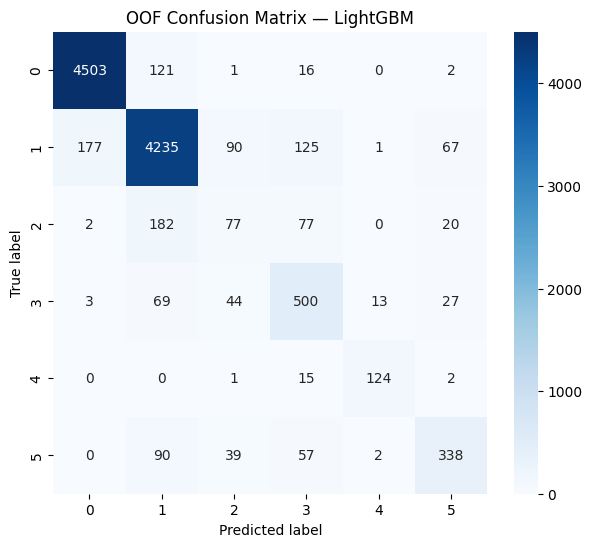

In [15]:
print(classification_report(y, oof_preds, digits=4))

cm = confusion_matrix(y, oof_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("OOF Confusion Matrix — LightGBM")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

,feature,importance
112,std_y_q25,200.4
28,mean_y_min,175.0
109,std_y_median,156.2
583,win4_std_y_min,148.4
168,acc_mag_iqr,145.2
29,mean_y_max,129.2
3,mean_x_max,127.0
4,mean_x_range,123.0
439,std_x_fft_spectral_entropy,122.4
166,acc_mag_q90,113.6


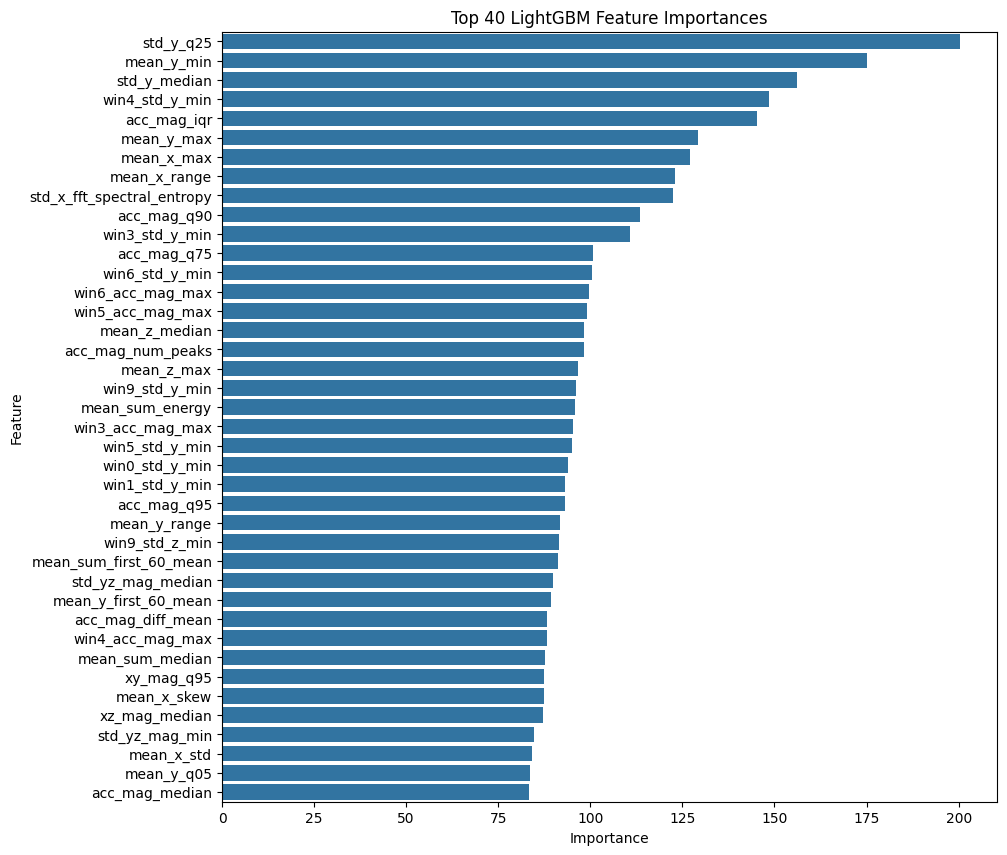

In [16]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": np.mean(
        [model.feature_importances_ for model in models],
        axis=0
    )
}).sort_values("importance", ascending=False)

display(importance_df.head(40))

plt.figure(figsize=(10, 10))
sns.barplot(data=importance_df.head(40), x="importance", y="feature")
plt.title("Top 40 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [17]:
test_proba = np.zeros((len(X_test_ordered), 6))

for model in models:
    test_proba += model.predict_proba(X_test_ordered) / len(models)

test_pred = np.argmax(test_proba, axis=1)

print("Prediction distribution:")
display(pd.Series(test_pred).value_counts().sort_index())

Prediction distribution:


0    2813
1    3074
2      98
3     505
4      95
5     264
Name: count, dtype: int64

In [18]:
submission = sample_submission.copy()
submission["Label"] = test_pred.astype(int)

display(submission.head())
display(submission["Label"].value_counts().sort_index())

submission.to_csv("submission_lightgbm.csv", index=False)

print("Saved submission_lightgbm.csv")

,Id,Label
0,11021,0
1,11022,0
2,11023,0
3,11024,0
4,11025,0


Label
0    2813
1    3074
2      98
3     505
4      95
5     264
Name: count, dtype: int64

Saved submission_lightgbm.csv
